# Validate conditional spin sampler

We verify that sampling $\chi_\mathrm{eff}$ from its analytic marginal
$p(\chi_\mathrm{eff} \mid q, \mathrm{iso})$ and then drawing
$(a_1, a_2, c_1, c_2) \mid \chi_\mathrm{eff}$ from `sample_conditional_spins`
recovers the flat isotropic prior
$$p(a_1, a_2, c_1, c_2) = U(a_1;[0,a_\max])\,U(a_2;[0,a_\max])\,U(c_1;[-1,1])\,U(c_2;[-1,1]).$$

A correct implementation should produce marginals that look **uniform** in each
variable, with no correlations.

In [11]:
import sys, os
sys.path.insert(0, os.getcwd())  # ensure sample_conditional_spins is importable

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import corner
from gwpopulation_pipe.analytic_spin_prior import chi_effective_prior_from_isotropic_spins
from sample_conditional_spins import sample_conditional_spins_batch

jax.config.update("jax_enable_x64", True)
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## Parameters — change these

In [12]:
q    = 0.8   # mass ratio (0 < q <= 1)
amax = 1.0   # maximum spin magnitude

N_samples = 100_000   # total spin samples to draw
n_grid    = 1_000   # grid resolution for chi1 CDF inversion
seed      = 42

## Step 1 — sample $\chi_\mathrm{eff}$ from the analytic marginal

We build a numerical CDF of $p(\chi_\mathrm{eff} \mid q, \mathrm{iso})$ using
`chi_effective_prior_from_isotropic_spins` and invert it.

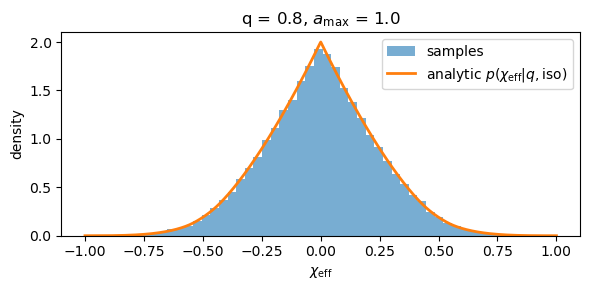

In [13]:
# Evaluate analytic p(chi_eff | q, iso) on a fine grid.
# Avoid the endpoints where the density diverges.
eps = 1e-6
chi_eff_grid = np.linspace(-amax + eps, amax - eps, 5_000)

p_chieff_vals = np.atleast_1d(
    chi_effective_prior_from_isotropic_spins(chi_eff_grid, q, amax)
)

# Trapezoidal CDF
dx = chi_eff_grid[1] - chi_eff_grid[0]
cdf_chieff = np.concatenate(
    [[0.0], np.cumsum((p_chieff_vals[:-1] + p_chieff_vals[1:]) / 2.0) * dx]
)
cdf_chieff /= cdf_chieff[-1]  # normalise to [0, 1]

# Inverse-CDF sampling
rng = np.random.default_rng(seed)
u_chieff = rng.uniform(size=N_samples)
chi_eff_samples = np.interp(u_chieff, cdf_chieff, chi_eff_grid)

# Quick sanity check: histogram should match analytic curve
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(chi_eff_samples, bins=50, density=True, alpha=0.6, label="samples")
ax.plot(chi_eff_grid, p_chieff_vals, lw=2, label=r"analytic $p(\chi_\mathrm{eff}|q,\mathrm{iso})$")
ax.set_xlabel(r"$\chi_\mathrm{eff}$")
ax.set_ylabel("density")
ax.legend()
ax.set_title(f"q = {q}, $a_{{\\max}}$ = {amax}")
plt.tight_layout()
plt.show()

## Step 2 — sample $(a_1, a_2, c_1, c_2)$ conditional on each $\chi_\mathrm{eff}$

All per-sample work (CDF grid build, inversion, analytic spin draw) is vmapped
over the full batch of $\chi_\mathrm{eff}$ values in a single JIT-compiled call —
no Python loop.

In [19]:
key = jax.random.PRNGKey(seed)
chi_eff_jax = jnp.array(chi_eff_samples)

a1_all, a2_all, c1_all, c2_all = sample_conditional_spins_batch(
    chi_eff_jax, q, key, amax, n_grid
)

# Verify chi_eff is recovered exactly (up to floating-point)
chi_eff_check = (a1_all * c1_all + q * a2_all * c2_all) / (1 + q)
max_err = float(jnp.max(jnp.abs(chi_eff_check - chi_eff_jax)))
print(f"Max |chi_eff_recovered - chi_eff_target| = {max_err:.2e}  (should be ~1e-15)")

Max |chi_eff_recovered - chi_eff_target| = 1.11e-16  (should be ~1e-15)


## Step 3 — corner plot

If the sampler is correct, each marginal should be uniform over its support
and all off-diagonal panels should show no structure.

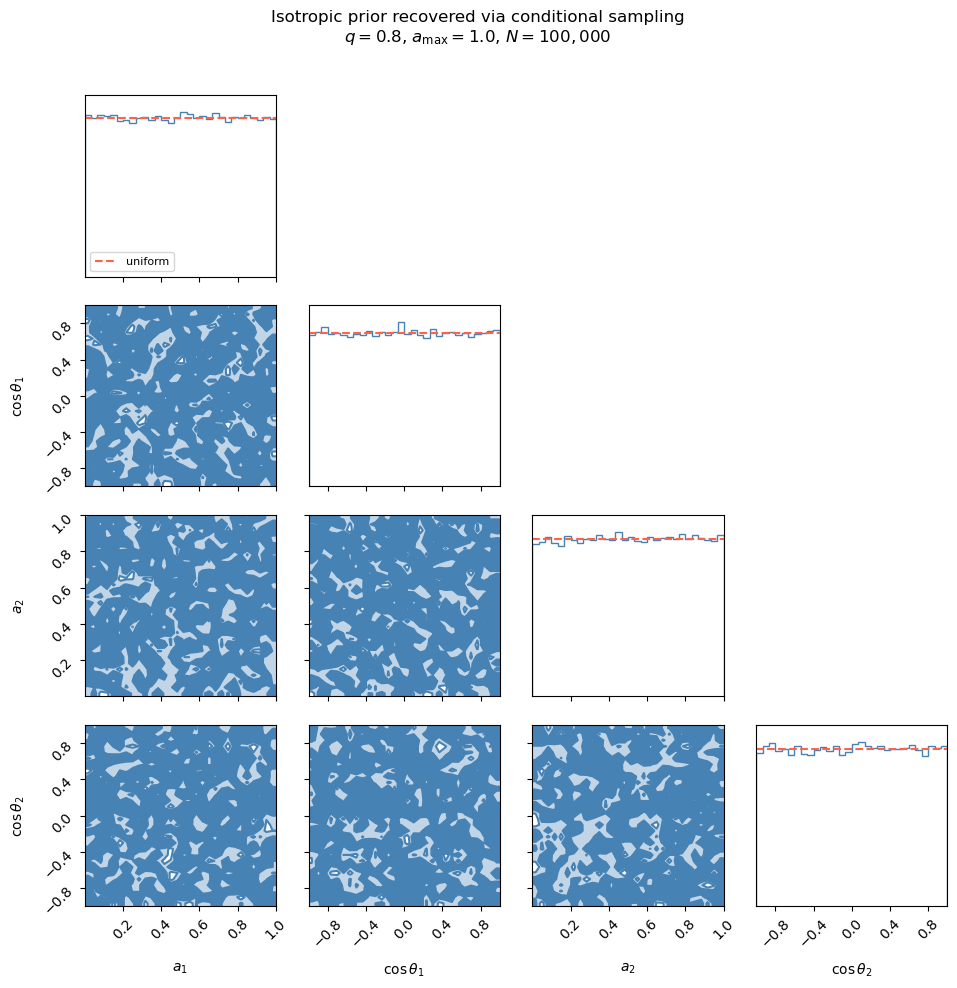

In [18]:
def plot_corner(a1_all, a2_all, c1_all, c2_all):

    samples_array = np.column_stack([
        np.array(a1_all), np.array(c1_all),
        np.array(a2_all), np.array(c2_all),
    ])

    labels = [r"$a_1$", r"$\cos\theta_1$", r"$a_2$", r"$\cos\theta_2$"]
    ranges = [(0, amax), (-1, 1), (0, amax), (-1, 1)]
    n_bins = 30

    fig = corner.corner(
        samples_array,
        labels=labels,
        range=ranges,
        bins=n_bins,
        plot_datapoints=False,
        plot_density=True,
        fill_contours=True,
        levels=(0.68, 0.95),
        color="steelblue",
    )

    # Overlay expected flat marginals in count units (smooth1d uses ax.plot, not ax.hist)
    axes = np.array(fig.axes).reshape(len(labels), len(labels))
    expected_count = N_samples / n_bins
    for i in range(len(labels)):
        ax = axes[i, i]
        ax.axhline(expected_count, color="tomato", lw=1.5, ls="--", label="uniform")
        if i == 0:
            ax.legend(fontsize=8)

    fig.suptitle(
        f"Isotropic prior recovered via conditional sampling\n"
        f"$q={q}$, $a_{{\\max}}={amax}$, $N={N_samples:,}$",
        y=1.02, fontsize=12,
    )
    plt.tight_layout()
    plt.show()
plot_corner(a1_all, a2_all, c1_all, c2_all)

## Fixed Xeff value

Xeff = 0.5, q = 0.35

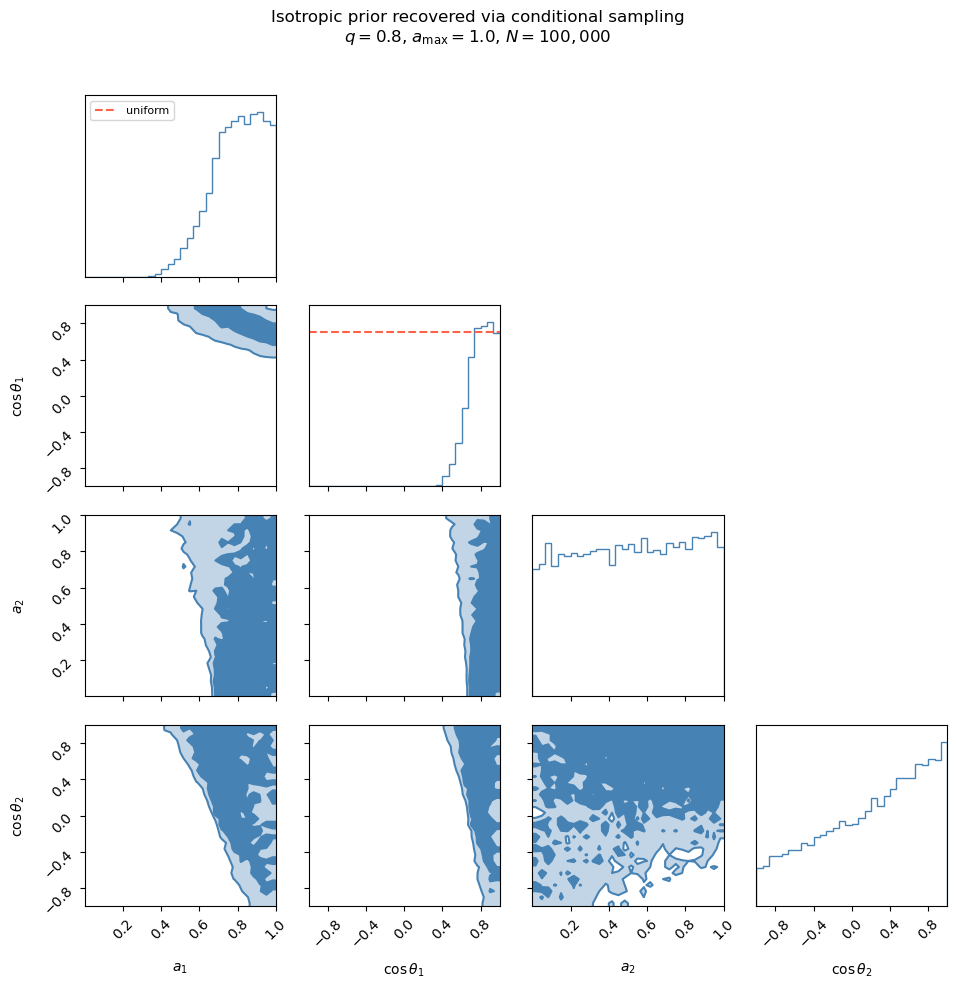

In [32]:
chi_eff = 0.5
chi_eff_jax = jnp.full(20_000, chi_eff)

a1_all, a2_all, c1_all, c2_all = sample_conditional_spins_batch(
    chi_eff_jax, 0.35, key, amax, n_grid
)
plot_corner(a1_all, a2_all, c1_all, c2_all)

Xeff = 0, q=1

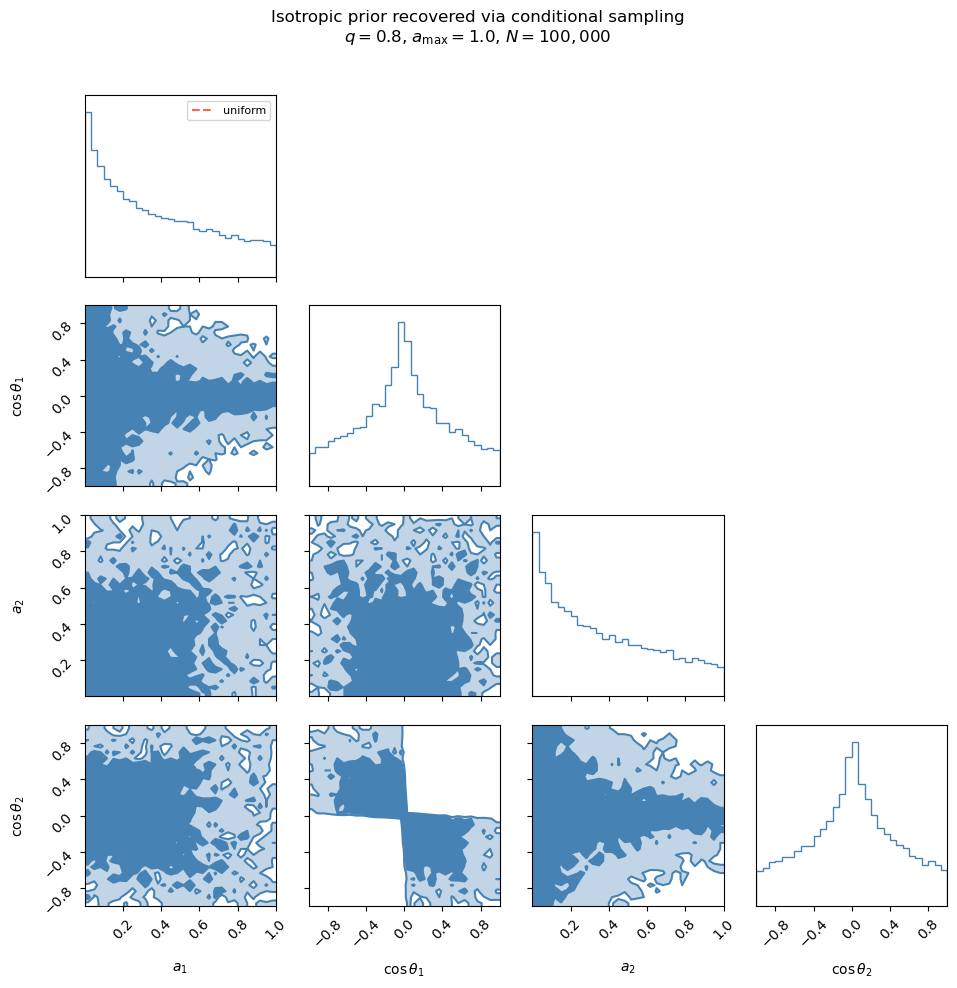

In [33]:
chi_eff = 0.0
chi_eff_jax = jnp.full(20_000, chi_eff)

a1_all, a2_all, c1_all, c2_all = sample_conditional_spins_batch(
    chi_eff_jax, 1., key, amax, n_grid
)
plot_corner(a1_all, a2_all, c1_all, c2_all)